# Graded Response Model — TMA (Single Scale)

Fits a single-dimensional GRM to all 50 TMA items. With binary responses (K=2), this is equivalent to a 2PL IRT model.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['TQDM_DISABLE'] = '1'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from plot_helpers import (plot_loss_comparison, plot_forest_discriminations,
                          plot_ability_scatter, plot_ability_distributions,
                          plot_thresholds, plot_individual_abilities,
                          plot_imputation_weights_pcolormesh)

## 1. Load Data

In [2]:
from bayesianquilts.data.tma import get_data, item_keys, response_cardinality

df, num_people = get_data(polars_out=True)
print(f"Dataset shape: {df.shape}")
print(f"Number of people: {num_people}")
print(f"Number of items: {len(item_keys)}")
print(f"Response cardinality: {response_cardinality} (binary: 0=False, 1=True)")
df.head()

Dataset shape: (5410, 51)
Number of people: 5410
Number of items: 50
Response cardinality: 2 (binary: 0=False, 1=True)


person,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,Q45,Q46,Q47,Q48,Q49,Q50
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,1,1,1,0,1,0,1,1,0,1,0,0,1,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,1
1,0,1,0,0,1,0,0,1,0,1,0,0,1,1,1,1,0,0,1,1,1,1,0,0,0,0,1,0,0,1,1,0,1,1,0,1,0,1,1,1,0,0,1,1,1,1,1,1,1,1
2,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,1,1,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,1
3,0,1,1,0,0,0,0,1,1,1,0,1,1,1,0,0,1,0,1,0,1,0,0,1,0,0,0,0,1,1,1,1,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1
4,0,1,1,0,0,1,0,0,0,0,0,1,1,1,0,0,0,1,1,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 5410


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 2612
N: 5410, Batch size: 256, Steps per epoch: 22


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
    snapshot_epoch=SNAPSHOT_EPOCH,
    lr_decay_factor=0.975,
)

losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Baseline final loss: {losses_baseline[-1]:.2f}")
if snapshot_params is not None:
    print(f"Snapshot saved at epoch {SNAPSHOT_EPOCH}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/22 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/22 [00:01<?, ?batch/s, best_loss=inf, loss=39.9775]

Epoch 1/200 (LR: 0.000200):   5%|▍         | 1/22 [00:01<00:25,  1.21s/batch, best_loss=inf, loss=39.9775]

Epoch 1/200 (LR: 0.000200):   5%|▍         | 1/22 [00:01<00:25,  1.21s/batch, best_loss=inf, loss=39.8017]

...

Epoch 15/200 (LR: 0.000137):   9%|▉         | 2/22 [00:00<00:03,  6.45batch/s, best_loss=38.3025, loss=39.7536]

Epoch 15/200 (LR: 0.000137):   9%|▉         | 2/22 [00:00<00:03,  6.45batch/s, best_loss=38.3025, loss=40.1305]

Epoch 15/200 (LR: 0.000137):   9%|▉         | 2/22 [00:00<00:03,  6.45batch/s, best_loss=38.3025, loss=39.8772]

Epoch 15/200 (LR: 0.000137):   9%|▉         | 2/22 [00:00<00:03,  6.45batch/s, best_loss=38.3025, loss=9.1428] 

   -> Reduced learning rate to: 0.000133
   -> Reinitialized optimizer and gradient accumulator
🔧 NaN/Inf detected in loss (loss) at epoch 15, step 304.
   Recovery attempt 4/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000130
   -> Reinitialized optimizer and gradient accumulator
  -> No improvement in loss for 10 check(s).                    
  -> Decaying learning rate to: 0.000127

Early stopping triggered after 10 epochs with no improvement.

--- Training Finished ---
NaN/Inf recovery was triggered 4 times during training.
Baseline final loss: 38.47


In [6]:
model_baseline.save_to_disk('grm_baseline')

In [7]:
# Calibrate baseline model early so we can compute WAIC for mixed imputation
def calibrate_manually(model, n_samples=32, seed=42):
    try:
        surrogate = model.surrogate_distribution_generator(model.params)
        key = jax.random.PRNGKey(seed)
        samples = surrogate.sample(n_samples, seed=key)
        expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
        model.calibrated_expectations = expectations
        model.surrogate_sample = samples
    except KeyError as e:
        print(f"  Warning: surrogate sampling failed ({e}), using point estimates")
        point_estimates = {}
        for key_name, value in model.params.items():
            parts = key_name.split('\\')
            if len(parts) >= 4:
                param_name = parts[0]
                if parts[-2] == 'normal' and parts[-1] == 'loc':
                    point_estimates[param_name] = value
        model.calibrated_expectations = point_estimates

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 4. Fit Pairwise Ordinal Stacking Model

In [8]:
from bayesianquilts.imputation.pairwise_stacking import PairwiseOrdinalStackingModel

# Convert to pandas, replacing -1 (missing marker) with NaN
pandas_df = sub_df.select(item_keys).to_pandas()
pandas_df = pandas_df.replace(-1, np.nan)
print(f"Missing values per item:\n{pandas_df.isna().sum()}")

pairwise_model = PairwiseOrdinalStackingModel(
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

pairwise_model.fit(
    pandas_df,
    n_top_features=50,
    n_jobs=1,
    seed=42,
)

Missing values per item:
Q1     31
Q2     42
Q3     32
Q4     32
Q5     34
Q6     45
Q7     44
Q8     56
Q9     48
Q10    43
Q11    41
Q12    53
Q13    51
Q14    59
Q15    69
Q16    61
Q17    52
Q18    45
Q19    38
Q20    49
Q21    64
Q22    53
Q23    48
Q24    31
Q25    40
Q26    60
Q27    51
Q28    59
Q29    42
Q30    59
Q31    54
Q32    64
Q33    57
Q34    50
Q35    53
Q36    76
Q37    52
Q38    56
Q39    50
Q40    50
Q41    64
Q42    58
Q43    65
Q44    76
Q45    63
Q46    67
Q47    62
Q48    65
Q49    54
Q50    44
dtype: int64
Computing feature correlations...
Fitting PairwiseOrdinalStackingModel
  Variables: 50
  Observations: 5410
  Min obs per model: 5
  Parallel jobs: 1
  Top features per target: 50
  DM alpha prior: 0.5

Fitting marginal regression models...
  50 of 50 remaining


  Var 0 (Q1): elpd/n=-0.0643


  Var 1 (Q2): elpd/n=-0.0644


  Var 2 (Q3): elpd/n=-0.0578


  Var 3 (Q4): elpd/n=-0.0657


...

  DM (Q3->Q49): elpd/n=-0.6531, n=5334
  DM (Q4->Q49): elpd/n=-0.6495, n=5336
  DM (Q5->Q49): elpd/n=-0.6575, n=5334
  DM (Q6->Q49): elpd/n=-0.6370, n=5323
  DM (Q7->Q49): elpd/n=-0.6529, n=5323
  DM (Q8->Q49): elpd/n=-0.6438, n=5313
  DM (Q9->Q49): elpd/n=-0.6563, n=5322
  DM (Q10->Q49): elpd/n=-0.6570, n=5326
  DM (Q11->Q49): elpd/n=-0.6279, n=5328
  DM (Q12->Q49): elpd/n=-0.6510, n=5317
  DM (Q13->Q49): elpd/n=-0.6476, n=5317
  DM (Q14->Q49): elpd/n=-0.6492, n=5310
  DM (Q15->Q49): elpd/n=-0.6620, n=5301
  DM (Q16->Q49): elpd/n=-0.6502, n=5307
  DM (Q17->Q49): elpd/n=-0.6443, n=5316
  DM (Q18->Q49): elpd/n=-0.6475, n=5325
  DM (Q19->Q49): elpd/n=-0.6558, n=5332
  DM (Q20->Q49): elpd/n=-0.6565, n=5320
  DM (Q21->Q49): elpd/n=-0.6475, n=5306
  DM (Q22->Q49): elpd/n=-0.6471, n=5317
  DM (Q23->Q49): elpd/n=-0.6491, n=5323
  DM (Q24->Q49): elpd/n=-0.6436, n=5339
  DM (Q25->Q49): elpd/n=-0.6159, n=5329


  DM (Q26->Q49): elpd/n=-0.6346, n=5330
  DM (Q27->Q49): elpd/n=-0.6293, n=5339
  DM (Q28->Q49): elpd/n=-0.6189, n=5331
  DM (Q29->Q49): elpd/n=-0.6314, n=5346
  DM (Q30->Q49): elpd/n=-0.6393, n=5329
  DM (Q31->Q49): elpd/n=-0.6127, n=5334
  DM (Q32->Q49): elpd/n=-0.6214, n=5325
  DM (Q33->Q49): elpd/n=-0.6307, n=5332
  DM (Q34->Q49): elpd/n=-0.6409, n=5338
  DM (Q35->Q49): elpd/n=-0.6527, n=5335
  DM (Q36->Q49): elpd/n=-0.6051, n=5312
  DM (Q37->Q49): elpd/n=-0.6294, n=5337
  DM (Q38->Q49): elpd/n=-0.6375, n=5333
  DM (Q39->Q49): elpd/n=-0.6216, n=5339
  DM (Q40->Q49): elpd/n=-0.6102, n=5339
  DM (Q41->Q49): elpd/n=-0.6114, n=5325
  DM (Q42->Q49): elpd/n=-0.6373, n=5330
  DM (Q43->Q49): elpd/n=-0.6314, n=5324
  DM (Q44->Q49): elpd/n=-0.6507, n=5316
  DM (Q45->Q49): elpd/n=-0.6104, n=5326
  DM (Q46->Q49): elpd/n=-0.5954, n=5322
  DM (Q47->Q49): elpd/n=-0.5970, n=5327
  DM (Q48->Q49): elpd/n=-0.5953, n=5326


  DM (Q50->Q49): elpd/n=-0.6239, n=5344
  DM (Q1->Q50): elpd/n=-0.3937, n=5344
  DM (Q2->Q50): elpd/n=-0.4056, n=5333
  DM (Q3->Q50): elpd/n=-0.3998, n=5344
  DM (Q4->Q50): elpd/n=-0.4014, n=5345
  DM (Q5->Q50): elpd/n=-0.4082, n=5344
  DM (Q6->Q50): elpd/n=-0.3991, n=5332
  DM (Q7->Q50): elpd/n=-0.4038, n=5333
  DM (Q8->Q50): elpd/n=-0.4033, n=5323
  DM (Q9->Q50): elpd/n=-0.4064, n=5331
  DM (Q10->Q50): elpd/n=-0.4067, n=5336
  DM (Q11->Q50): elpd/n=-0.3893, n=5338
  DM (Q12->Q50): elpd/n=-0.4013, n=5326
  DM (Q13->Q50): elpd/n=-0.4038, n=5328
  DM (Q14->Q50): elpd/n=-0.4032, n=5320
  DM (Q15->Q50): elpd/n=-0.4106, n=5309
  DM (Q16->Q50): elpd/n=-0.4052, n=5317
  DM (Q17->Q50): elpd/n=-0.3988, n=5326
  DM (Q18->Q50): elpd/n=-0.3971, n=5334
  DM (Q19->Q50): elpd/n=-0.4088, n=5342
  DM (Q20->Q50): elpd/n=-0.4082, n=5330
  DM (Q21->Q50): elpd/n=-0.4021, n=5315
  DM (Q22->Q50): elpd/n=-0.3980, n=5326
  DM (Q23->Q50): elpd/n=-0.4037, n=5331


  DM (Q24->Q50): elpd/n=-0.4044, n=5348
  DM (Q25->Q50): elpd/n=-0.3722, n=5340
  DM (Q26->Q50): elpd/n=-0.3872, n=5338
  DM (Q27->Q50): elpd/n=-0.3902, n=5347
  DM (Q28->Q50): elpd/n=-0.3818, n=5339
  DM (Q29->Q50): elpd/n=-0.3886, n=5356
  DM (Q30->Q50): elpd/n=-0.3934, n=5339
  DM (Q31->Q50): elpd/n=-0.3874, n=5344
  DM (Q32->Q50): elpd/n=-0.3796, n=5334
  DM (Q33->Q50): elpd/n=-0.3978, n=5341
  DM (Q34->Q50): elpd/n=-0.4052, n=5348
  DM (Q35->Q50): elpd/n=-0.4083, n=5345
  DM (Q36->Q50): elpd/n=-0.3843, n=5323
  DM (Q37->Q50): elpd/n=-0.3943, n=5346
  DM (Q38->Q50): elpd/n=-0.3838, n=5342
  DM (Q39->Q50): elpd/n=-0.3871, n=5348
  DM (Q40->Q50): elpd/n=-0.3660, n=5348
  DM (Q41->Q50): elpd/n=-0.3924, n=5334
  DM (Q42->Q50): elpd/n=-0.3801, n=5341
  DM (Q43->Q50): elpd/n=-0.3900, n=5334
  DM (Q44->Q50): elpd/n=-0.4062, n=5322
  DM (Q45->Q50): elpd/n=-0.3942, n=5336
  DM (Q46->Q50): elpd/n=-0.3525, n=5332


  DM (Q47->Q50): elpd/n=-0.3064, n=5337
  DM (Q48->Q50): elpd/n=-0.3757, n=5333
  DM (Q49->Q50): elpd/n=-0.3728, n=5344

Completed:
  Regression marginal: 50/50
  Regression univariate: 2294/2450
  DM marginal: 50/50
  DM pairwise: 2450/2450


In [9]:
pairwise_model.save('pairwise_stacking_model.yaml')
pairwise_model.compute_optimal_stacking_weights()

Optimal stacking weights computed for 50 targets


In [10]:
import pandas as pd

def compare_stacking_weights(model, item_keys):
    """Compare default softmax vs optimal Yao et al. stacking weights."""
    rows = []
    for i, item_key in enumerate(item_keys):
        models_info = []
        if i in model.marginal_results:
            zr = model.marginal_results[i]
            if zr.converged:
                models_info.append(("reg:intercept", zr.elpd_loo_per_obs, zr.elpd_loo_per_obs_se, 0.0))
        for (t, p), r in model.univariate_results.items():
            if t == i and r.converged:
                pred_name = model.variable_names[p] if p < len(model.variable_names) else str(p)
                models_info.append((f"reg:{pred_name}", r.elpd_loo_per_obs, r.elpd_loo_per_obs_se, 0.0))
        if hasattr(model, "dm_zero_results") and i in model.dm_zero_results:
            dmz = model.dm_zero_results[i]
            if dmz.converged:
                models_info.append(("dm:marginal", dmz.elpd_loo_per_obs, dmz.elpd_loo_per_obs_se, 0.0))
        if hasattr(model, "dm_results"):
            for (t, p), r in model.dm_results.items():
                if t == i and r.converged:
                    pred_name = model.variable_names[p] if p < len(model.variable_names) else str(p)
                    models_info.append((f"dm:{pred_name}", r.elpd_loo_per_obs, r.elpd_loo_per_obs_se, 0.0))
        n_models = len(models_info)
        if n_models == 0:
            rows.append({"Item": item_key, "N": 0, "Eff_def": "-", "Eff_opt": "-",
                         "Top_default": "-", "w_def": "-", "Top_optimal": "-", "w_opt": "-"})
            continue
        elpds = np.array([m[1] for m in models_info])
        ses = np.array([m[2] for m in models_info])
        default_w = model._elpd_weights(elpds, ses, 1.0)
        opt_dict = getattr(model, "_optimal_weights", {}).get(i, {})
        opt_w = np.zeros(n_models)
        for j, (name, _, _, _) in enumerate(models_info):
            parts = name.split(":", 1)
            mtype, mid = parts[0], parts[1] if len(parts) > 1 else ""
            if mid in ("intercept", "marginal"):
                key = (mtype[:3], mid)
            elif mid in model.variable_names:
                key = (mtype[:3], model.variable_names.index(mid))
            else:
                key = (mtype[:3], mid)
            opt_w[j] = opt_dict.get(key, 0.0)
        if opt_w.sum() > 0: opt_w /= opt_w.sum()
        def eff_n(w):
            w = w[w > 1e-10]
            return float(np.exp(-np.sum(w * np.log(w)))) if len(w) > 0 else 0
        names = [m[0] for m in models_info]
        rows.append({
            "Item": item_key, "N": n_models,
            "Eff_def": f"{eff_n(default_w):.1f}", "Eff_opt": f"{eff_n(opt_w):.1f}",
            "Top_default": names[np.argmax(default_w)], "w_def": f"{default_w.max():.3f}",
            "Top_optimal": names[np.argmax(opt_w)] if opt_w.sum() > 0 else "-",
            "w_opt": f"{opt_w.max():.3f}",
        })
    return pd.DataFrame(rows)

weights_df = compare_stacking_weights(pairwise_model, item_keys)
print("Stacking Weights: Default (softmax) vs Optimal (Yao et al. 2018)\n")
print(weights_df.to_string(index=False))

Stacking Weights: Default (softmax) vs Optimal (Yao et al. 2018)

Item   N Eff_def Eff_opt   Top_default w_def   Top_optimal w_opt
  Q1  94    90.2    94.0       reg:Q41 0.014 reg:intercept 0.011
  Q2  96    92.0    96.0       reg:Q33 0.014 reg:intercept 0.010
  Q3  95    91.4    95.0       reg:Q49 0.014 reg:intercept 0.011
  Q4  99    94.6    99.0        reg:Q2 0.013 reg:intercept 0.010
  Q5  98    94.2    98.0       reg:Q31 0.013 reg:intercept 0.010
  Q6  98    95.5    98.0       reg:Q41 0.013 reg:intercept 0.010
  Q7  90    87.2    90.0       reg:Q34 0.014 reg:intercept 0.011
  Q8  97    92.9    97.0       reg:Q48 0.013 reg:intercept 0.010
  Q9  99    94.5    99.0       reg:Q12 0.013 reg:intercept 0.010
 Q10  96    91.6    96.0       reg:Q21 0.014 reg:intercept 0.010
 Q11  98    96.3    98.0       reg:Q27 0.012 reg:intercept 0.010
 Q12  96    91.9    96.0       reg:Q13 0.014 reg:intercept 0.010
 Q13  99    95.6    99.0       reg:Q25 0.013 reg:intercept 0.010
 Q14  99    95.1    99.0

## 4b. Fit Pairwise-Only GRM

Uses only the pairwise ordinal stacking ensemble (no IRT blending, w=1 for all items).

In [11]:
from bayesianquilts.imputation.mixed import PairwiseOnlyImputationModel

pairwise_imputation = PairwiseOnlyImputationModel(mice_model=pairwise_model)

model_pairwise = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    imputation_model=pairwise_imputation,
    dtype=jnp.float64,
)

print("Warm-starting from baseline model parameters")

res_pairwise = model_pairwise.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
    initial_values=model_baseline.params,
    lr_decay_factor=0.975,
)

losses_pairwise = res_pairwise[0]
print(f"Final pairwise loss: {losses_pairwise[-1]:.2f}")
model_pairwise.save_to_disk('grm_pairwise')

Warm-starting from baseline model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/22 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/22 [00:01<?, ?batch/s, best_loss=inf, loss=40.3248]

Epoch 1/200 (LR: 0.000200):   5%|▍         | 1/22 [00:01<00:32,  1.55s/batch, best_loss=inf, loss=40.3248]

Epoch 1/200 (LR: 0.000200):   5%|▍         | 1/22 [00:01<00:32,  1.55s/batch, best_loss=inf, loss=40.5114]

...

Epoch 18/200 (LR: 0.000112):  86%|████████▋ | 19/22 [00:00<00:00, 26.16batch/s, best_loss=38.5439, loss=40.5874]

Epoch 18/200 (LR: 0.000112):  86%|████████▋ | 19/22 [00:00<00:00, 26.16batch/s, best_loss=38.5439, loss=40.1001]

Epoch 18/200 (LR: 0.000112):  86%|████████▋ | 19/22 [00:00<00:00, 26.16batch/s, best_loss=38.5439, loss=40.4590]

Epoch 18/200 (LR: 0.000112):  86%|████████▋ | 19/22 [00:00<00:00, 26.16batch/s, best_loss=38.5439, loss=9.0817] 

  -> No improvement in loss for 10 check(s).                    
  -> Decaying learning rate to: 0.000109

Early stopping triggered after 10 epochs with no improvement.

--- Training Finished ---
NaN/Inf recovery was triggered 4 times during training.
Final pairwise loss: 38.95


In [12]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=pairwise_model,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

MICE pointwise ELPD computed for 50 items, 5410 people


Item Stacking Weights (Yao et al. 2018, MICE vs IRT):
Item           w_mice  ELPD_mice   ELPD_irt  khat_irt
-----------------------------------------------------
Q1              1.000    -0.6307    -0.9871     0.000
Q2              0.959    -0.6464    -0.7090     0.000
Q3              1.000    -0.6113    -0.8834     0.000
Q4              1.000    -0.6724    -0.8685     0.000
Q5              1.000    -0.6225    -0.8348     0.000
Q6              0.646    -0.4914    -0.5262     0.000
Q7              0.597    -0.5431    -0.5630     0.000
Q8              1.000    -0.6511    -0.7891     0.000
Q9              1.000    -0.6813    -0.7842     0.000
Q10             0.286    -0.6765    -0.6559     0.000
Q11             0.442    -0.3881    -0.3592     0.000
Q12             1.000    -0.6531    -1.0728     0.000
Q13             1.000    -0.5817    -0.8900     0.000
Q14             0.687    -0.6234    -0.6473     0.000
Q15             0.724    -0.6832    -0.7140     0.000
Q16             0.509    -0.

## 5. Fit Mixed GRM (Pairwise + IRT Imputation)

In [13]:
all_pairwise = all(mixed_imputation.get_item_weight(k) >= 1.0 - 1e-6 for k in item_keys)

if all_pairwise:
    print("All w_IRT ≈ 0 — mixed model is identical to pairwise. Reusing pairwise parameters.")
    model_imputed = model_pairwise
    losses_imputed = losses_pairwise
else:
    print(f"IRT contributes to {sum(1 for k in item_keys if mixed_imputation.get_item_weight(k) < 1.0 - 1e-6)}/{len(item_keys)} items")
    model_imputed = GRModel(
        item_keys=item_keys,
        num_people=SUBSAMPLE_N,
        dim=1,
        response_cardinality=response_cardinality,
        dtype=jnp.float64,
        imputation_model=mixed_imputation,
    )

    print("Warm-starting from pairwise model parameters")
    res_imputed = model_imputed.fit(
        data_factory,
        batch_size=BATCH_SIZE,
        dataset_size=SUBSAMPLE_N,
        num_epochs=NUM_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        learning_rate=0.0001,
        patience=10,
        lr_decay_factor=0.975,
        zero_nan_grads=True,
        initial_values=model_pairwise.params,
    )
    losses_imputed = res_imputed[0]
    if losses_imputed:
        print(f"Final mixed loss: {losses_imputed[-1]:.2f}")
    else:
        print("Mixed model training failed — falling back to pairwise")
        model_imputed = model_pairwise
        losses_imputed = losses_pairwise

IRT contributes to 33/50 items


Warm-starting from pairwise model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000100):   0%|          | 0/22 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000100):   0%|          | 0/22 [00:00<?, ?batch/s, best_loss=inf, loss=40.5653]

Epoch 1/200 (LR: 0.000100):   5%|▍         | 1/22 [00:00<00:18,  1.15batch/s, best_loss=inf, loss=40.5653]

...

Epoch 15/200 (LR: 0.000068):  82%|████████▏ | 18/22 [00:01<00:00, 12.18batch/s, best_loss=38.5096, loss=40.1811]

Epoch 15/200 (LR: 0.000068):  82%|████████▏ | 18/22 [00:01<00:00, 12.18batch/s, best_loss=38.5096, loss=40.3384]

Epoch 15/200 (LR: 0.000068):  82%|████████▏ | 18/22 [00:01<00:00, 12.18batch/s, best_loss=38.5096, loss=9.1107] 

   -> Reduced learning rate to: 0.000067
   -> Reinitialized optimizer and gradient accumulator
🔧 NaN/Inf detected in loss (loss) at epoch 15, step 319.
   Recovery attempt 4/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000065
   -> Reinitialized optimizer and gradient accumulator
  -> No improvement in loss for 10 check(s).                    
  -> Decaying learning rate to: 0.000063

Early stopping triggered after 10 epochs with no improvement.

--- Training Finished ---
NaN/Inf recovery was triggered 4 times during training.


Final mixed loss: 38.64


In [14]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

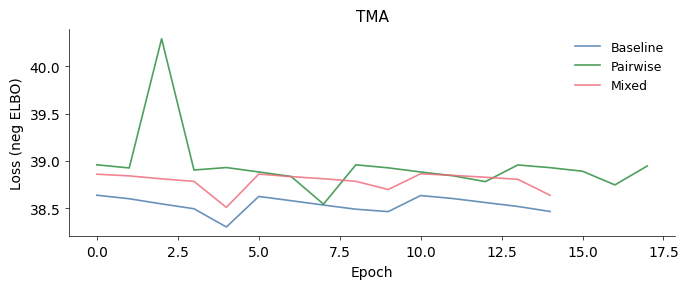

In [15]:
fig = plot_loss_comparison(losses_baseline, losses_imputed, title='TMA',
                          losses_pairwise=losses_pairwise)
fig.savefig('loss_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [16]:
# calibrate_manually already defined above; just calibrate the remaining models
calibrate_manually(model_pairwise, n_samples=32, seed=103)
calibrate_manually(model_imputed, n_samples=32, seed=102)

## 7. Ignorability Analysis

Compute per-item adaptive thresholds comparing pairwise imputation ELPD
against baseline IRT ELPD. Items whose missing values are **ignorable**
do not benefit from imputation over the baseline's own marginalization.

In [17]:
model_imputed.compute_adaptive_thresholds(
    data_factory, baseline_model=model_baseline, sample_size=32
)

import pandas as pd
ignorability_df = pd.DataFrame([
    {
        'Item': item,
        'w_pairwise': f"{mixed_imputation.get_item_weight(item):.4f}",
        'Threshold': f"{model_imputed._adaptive_thresholds[item]:.4f}",
        'Missing Ignorable': model_imputed._ignorable_items[item],
    }
    for item in item_keys
])
n_ignorable = sum(model_imputed._ignorable_items[k] for k in item_keys)
print(f"Ignorability: {n_ignorable}/{len(item_keys)} items have ignorable missing values\n")
print(ignorability_df.to_string(index=False))

model_imputed.save_to_disk('grm_imputed')

Ignorability: 0/50 items have ignorable missing values

Item w_pairwise Threshold  Missing Ignorable
  Q1     1.0000    0.0010              False
  Q2     0.9589    0.0010              False
  Q3     1.0000    0.0010              False
  Q4     1.0000    0.0010              False
  Q5     1.0000    0.0010              False
  Q6     0.6459    0.0010              False
  Q7     0.5973    0.0010              False
  Q8     1.0000    0.0010              False
  Q9     1.0000    0.0010              False
 Q10     0.2862    0.0010              False
 Q11     0.4417    0.0010              False
 Q12     1.0000    0.0010              False
 Q13     1.0000    0.0010              False
 Q14     0.6866    0.0010              False
 Q15     0.7241    0.0010              False
 Q16     0.5091    0.0010              False
 Q17     0.4180    0.0010              False
 Q18     1.0000    0.0010              False
 Q19     0.5414    0.0010              False
 Q20     1.0000    0.0010              False

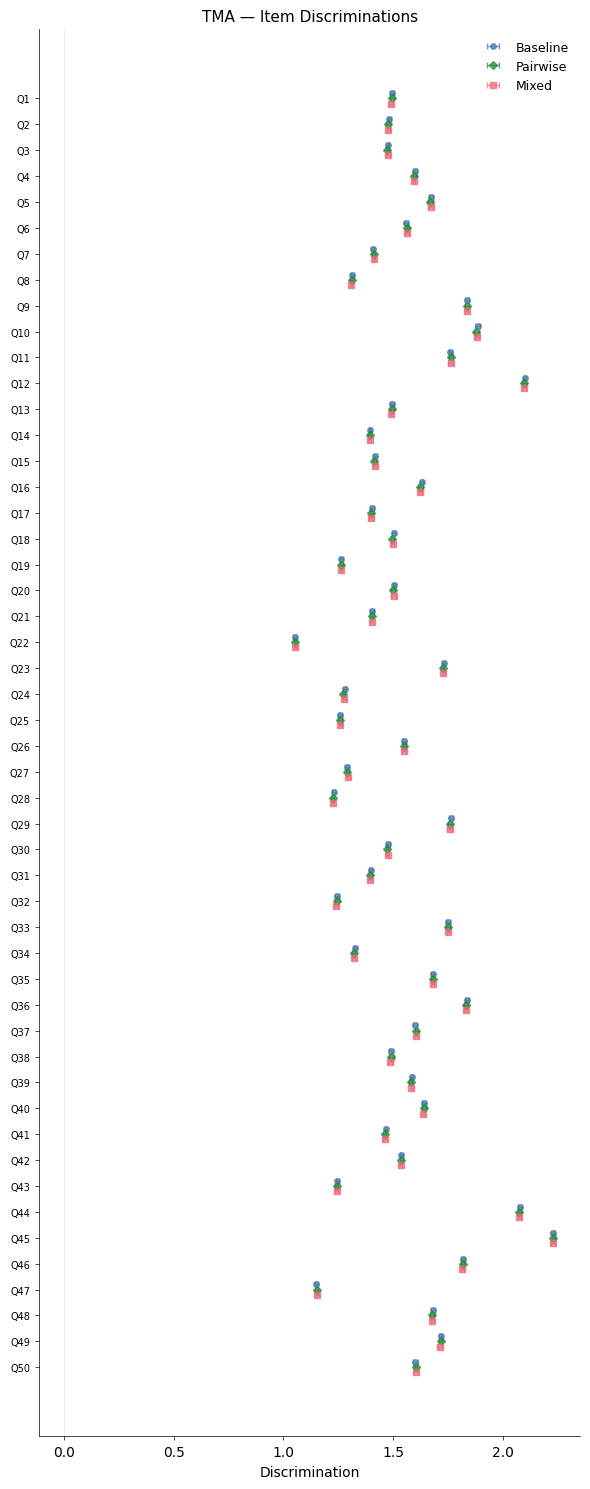

In [18]:
fig = plot_forest_discriminations(item_keys, model_baseline, model_imputed,
                                  model_pairwise=model_pairwise,
                                  title='TMA — Item Discriminations')
fig.savefig('discriminations.pdf', bbox_inches='tight', dpi=150)
plt.show()

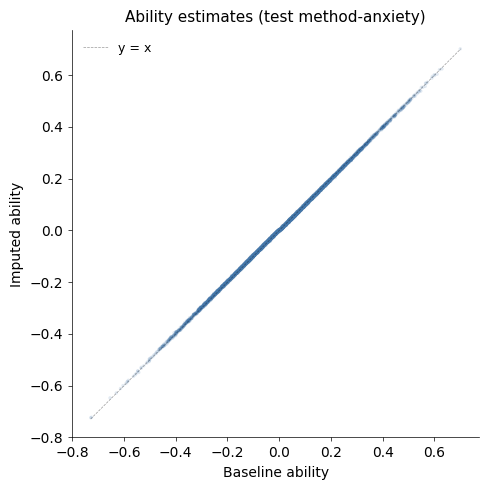

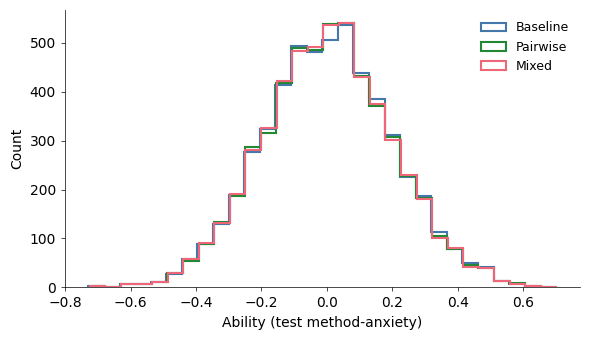

In [19]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_pw = np.array(model_pairwise.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig = plot_ability_scatter(ab_base, ab_imp, label='test method-anxiety')
fig.savefig('ability_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()

fig = plot_ability_distributions(ab_base, ab_imp, label='test method-anxiety',
                                  abilities_pairwise=ab_pw)
fig.savefig('ability_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

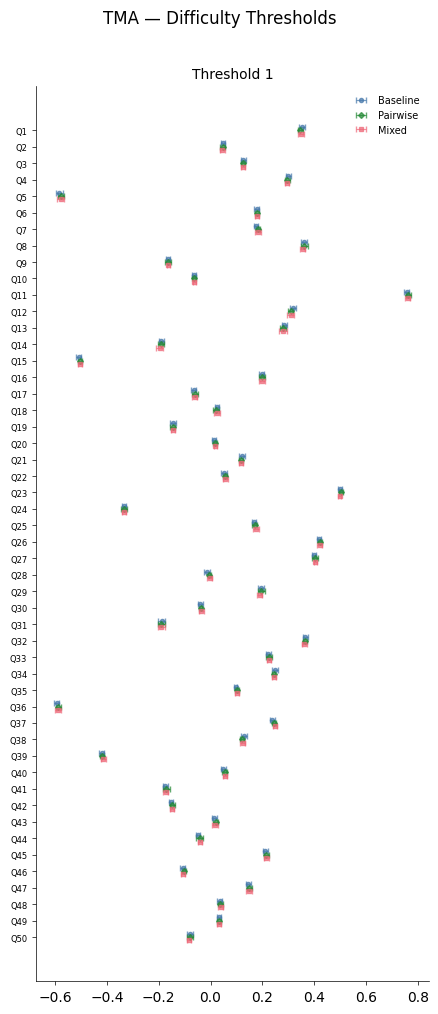

In [20]:
fig = plot_thresholds(item_keys, model_baseline, model_imputed,
                      model_pairwise=model_pairwise,
                      title='TMA — Difficulty Thresholds')
fig.savefig('thresholds.pdf', bbox_inches='tight', dpi=150)
plt.show()

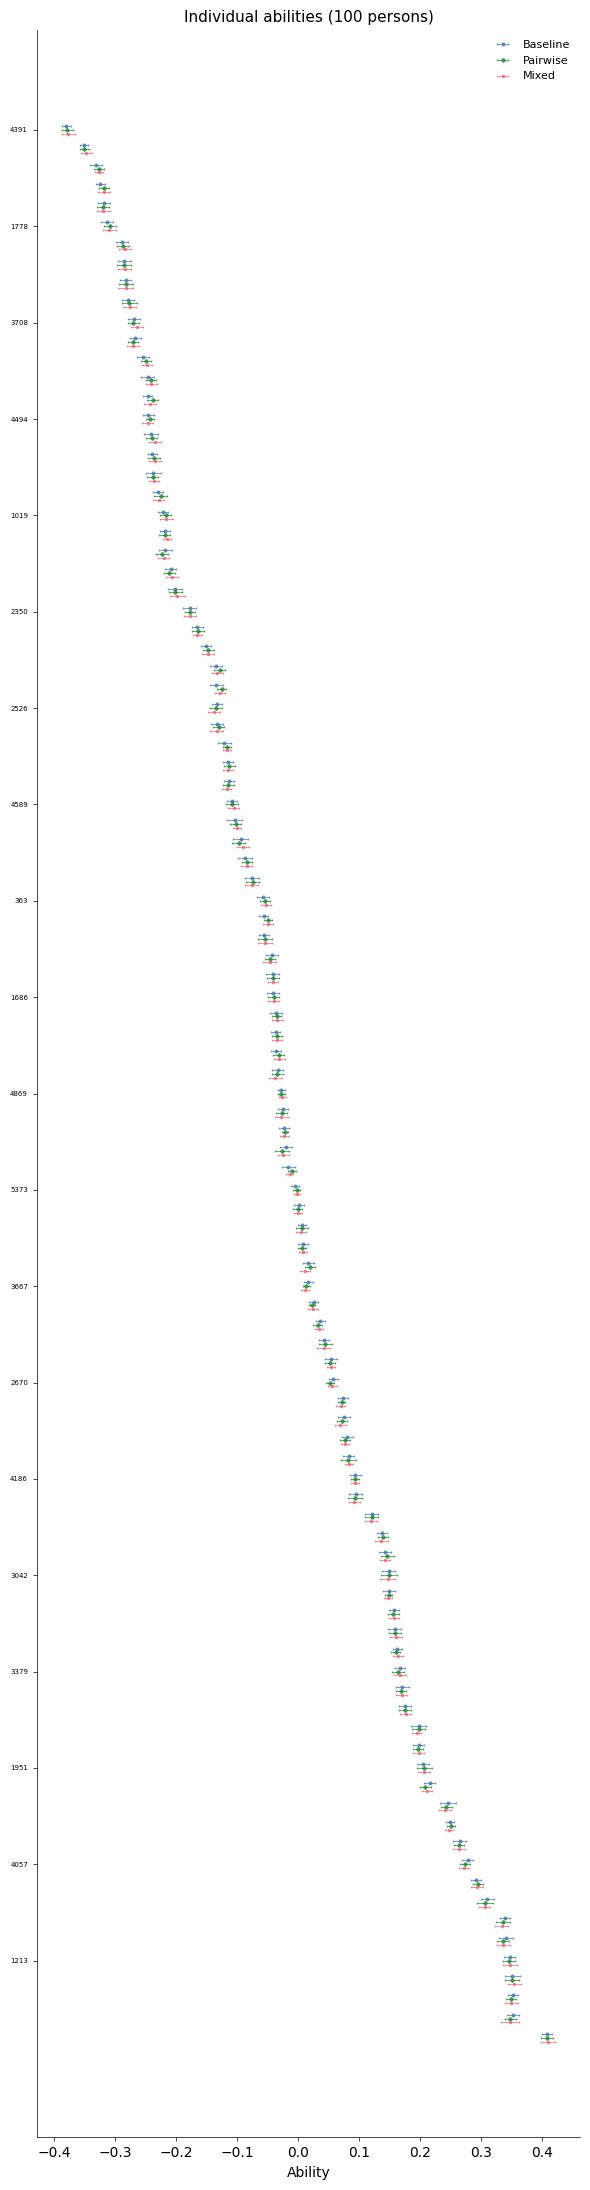

In [21]:
fig = plot_individual_abilities(item_keys, model_baseline, model_imputed,
                                model_pairwise=model_pairwise)
fig.savefig('individual_abilities.pdf', bbox_inches='tight', dpi=150)
plt.show()

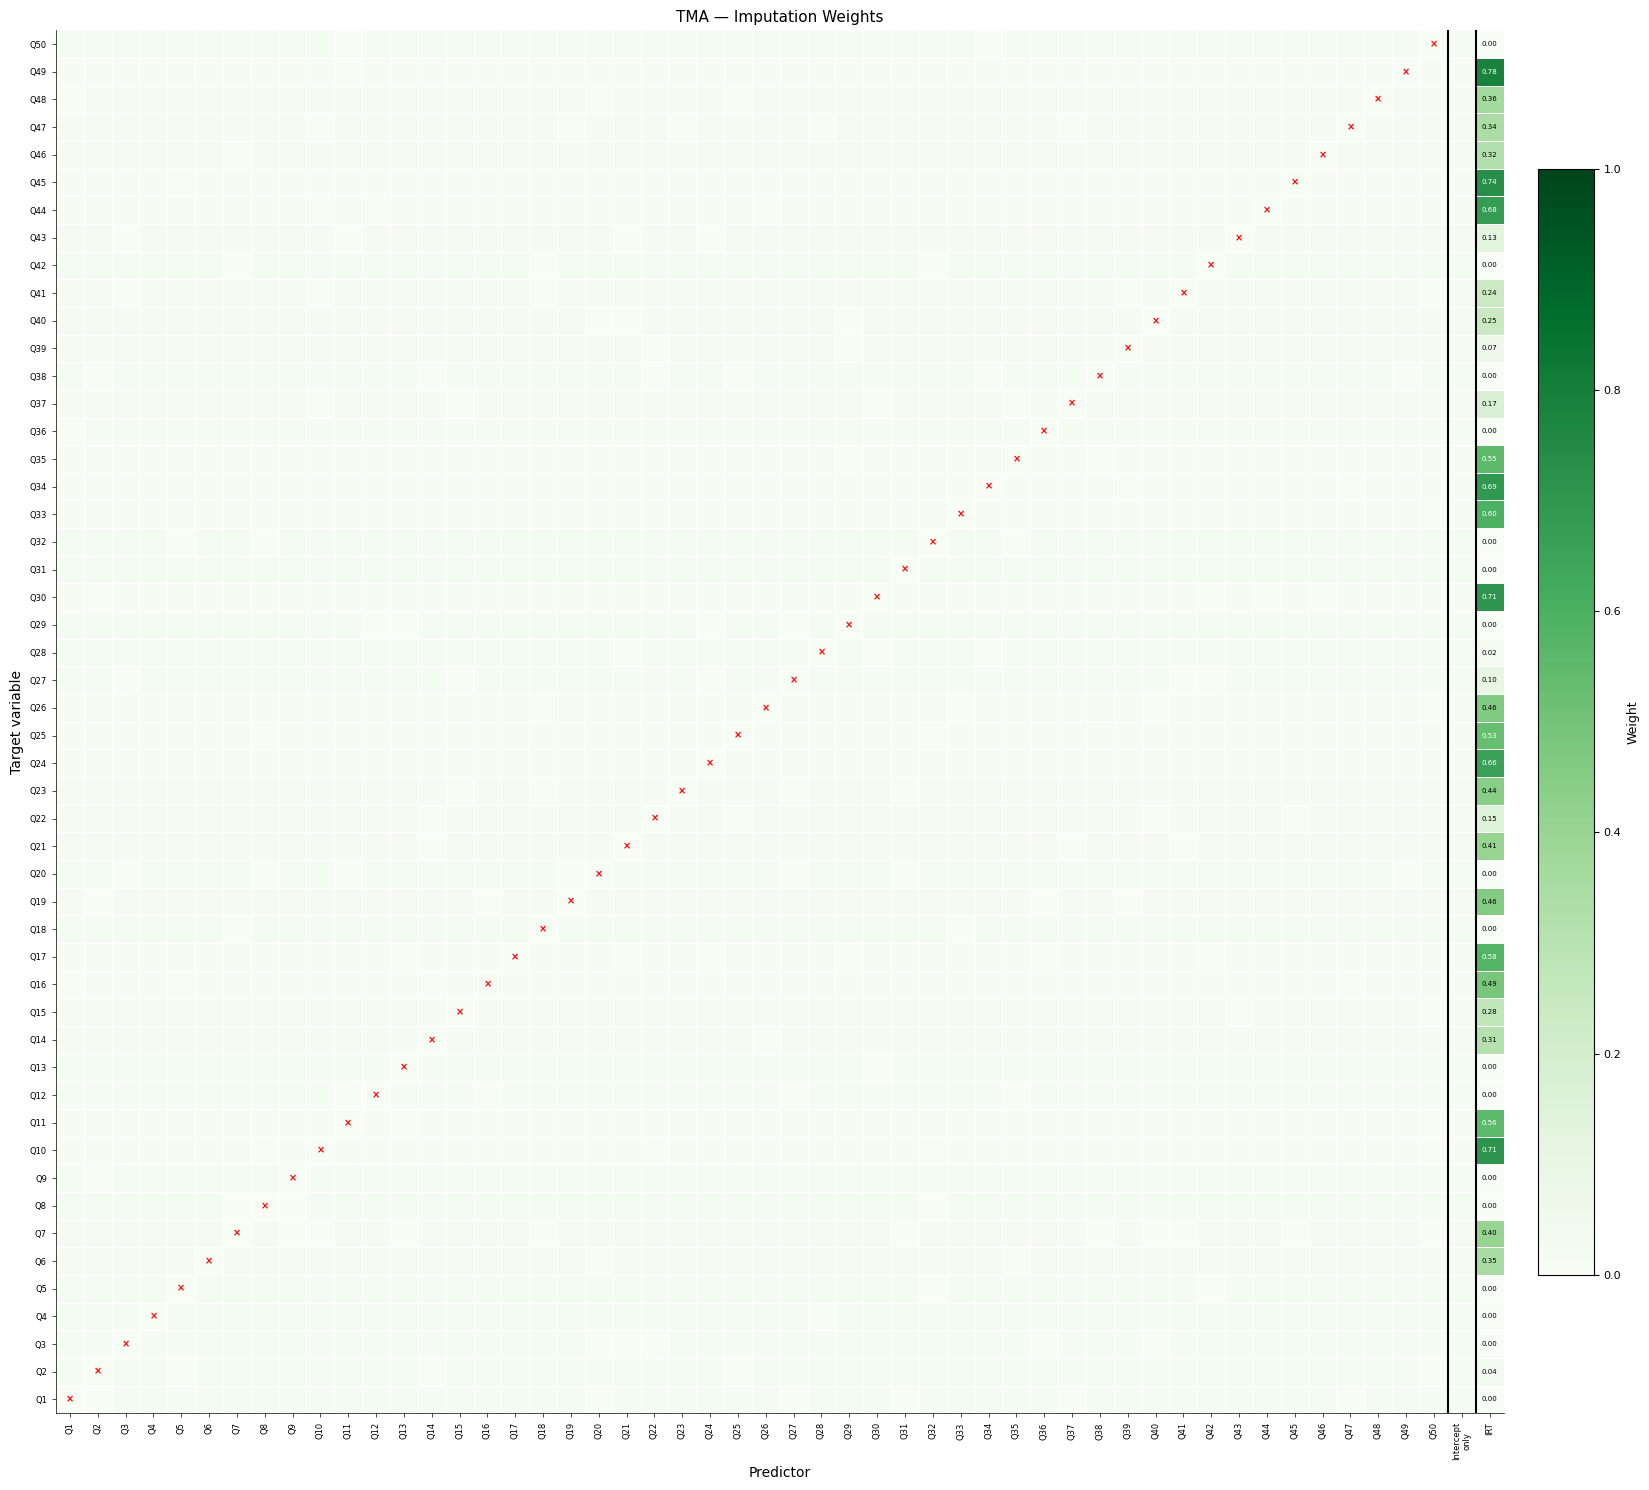

In [22]:
fig = plot_imputation_weights_pcolormesh(pairwise_model, mixed_imputation, item_keys,
                                          title='TMA — Imputation Weights')
fig.savefig('imputation_weights.pdf', bbox_inches='tight', dpi=150)
plt.show()

## Predictive Performance Comparison

In [23]:
import pandas as pd
from scipy.stats import spearmanr

def compute_predictive_metrics(model, data_factory, item_keys, response_cardinality):
    K = response_cardinality
    all_ll, all_se, all_nr = [], [], []
    all_pred, all_obs = [], []
    for batch_data in data_factory():
        pred = model.predictive_distribution(batch_data, **model.surrogate_sample)
        probs = np.array(pred['rv'].probs_parameter())
        S, N_batch, I, _ = probs.shape
        for n in range(N_batch):
            ll, se, nr = 0.0, 0.0, 0
            for i, key in enumerate(item_keys):
                y = batch_data[key][n]
                if np.isnan(y) or y < 0 or y >= K: continue
                y_int = int(y)
                p_mean = probs[:, n, i, :].mean(0)
                ll += np.log(np.maximum(probs[:, n, i, y_int].mean(), 1e-30))
                expected = np.sum(p_mean * np.arange(K))
                se += (expected - y_int) ** 2
                all_pred.append(expected)
                all_obs.append(y_int)
                nr += 1
            if nr > 0: all_ll.append(ll); all_se.append(se); all_nr.append(nr)
    ll, se, nr = np.array(all_ll), np.array(all_se), np.array(all_nr)
    N, total = len(ll), nr.sum()
    rho, _ = spearmanr(all_obs, all_pred)
    return {
        'RMSE': (np.sqrt(se.sum()/total), np.std(np.sqrt(se/nr))/np.sqrt(N)),
        'ELPD/n': (ll.mean(), np.std(ll)/np.sqrt(N)),
        'ELPD/resp': (ll.sum()/total, np.std(ll/nr)/np.sqrt(N)),
        'Spearman': (rho, 0.0),
    }

m_b = compute_predictive_metrics(model_baseline, data_factory, item_keys, response_cardinality)
m_p = compute_predictive_metrics(model_pairwise, data_factory, item_keys, response_cardinality)
m_m = compute_predictive_metrics(model_imputed, data_factory, item_keys, response_cardinality)

rows = []
for metric in ['RMSE', 'ELPD/n', 'ELPD/resp', 'Spearman']:
    b_val, b_se = m_b[metric]
    p_val, p_se = m_p[metric]
    m_val, m_se = m_m[metric]
    if metric == 'Spearman':
        rows.append({
            'Metric': metric,
            'Baseline': f"{b_val:.4f}",
            'Pairwise': f"{p_val:.4f}",
            'Mixed': f"{m_val:.4f}",
        })
    else:
        rows.append({
            'Metric': metric,
            'Baseline': f"{b_val:.3f} ({b_se:.3f})",
            'Pairwise': f"{p_val:.3f} ({p_se:.3f})",
            'Mixed': f"{m_val:.3f} ({m_se:.3f})",
        })
print("TMA — Predictive Performance Comparison\n")
print(pd.DataFrame(rows).to_string(index=False))


TMA — Predictive Performance Comparison

   Metric        Baseline        Pairwise           Mixed
     RMSE   0.513 (0.000)   0.512 (0.000)   0.512 (0.000)
   ELPD/n -35.814 (0.041) -35.735 (0.041) -35.729 (0.041)
ELPD/resp  -0.722 (0.001)  -0.720 (0.001)  -0.720 (0.001)


## Summary

This notebook demonstrated fitting a single-dimensional Graded Response Model to the
Taylor Manifest Anxiety Scale (TMA) dataset (50 binary items, K=2). With binary responses,
the GRM reduces to a 2PL IRT model.

Three models were fitted:

1. **Baseline (ignorable missingness)**: Missing responses have their log-likelihood
   contributions zeroed out, assuming the missingness mechanism is ignorable.
2. **Pairwise-only imputation**: A `PairwiseOrdinalStackingModel` provides imputation
   with w=1 for all items (no IRT blending). Missing cells are analytically marginalized
   over the pairwise imputation PMF (Rao-Blackwellization).
3. **Mixed imputation (Pairwise + IRT)**: The pairwise ordinal stacking model is blended
   with the baseline IRT model's marginalized predictions via per-item softmax weights
   over ELPD scores. Missing cells are analytically marginalized over the blended
   imputation PMF (Rao-Blackwellization).

The discrimination and ability estimates from all three approaches can be compared to assess
the impact of the missingness handling strategy on parameter recovery.